<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Wk7_Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score
%matplotlib inline

In [5]:
df = pd.read_csv('/content/Diabetes-Classification.csv')


print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (128, 11)

First 5 Rows:


,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [6]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values by dropping rows
df = df.dropna()


Missing Values:
Age                           0
Gender                        0
BMI                           3
Blood Pressure                0
FBS                           0
HbA1c                         0
Family History of Diabetes    2
Smoking                       2
Diet                          2
Exercise                      1
Diagnosis                     0
dtype: int64


In [7]:
# Check column names
print("\nColumn Names:")
print(df.columns)

# Preprocessing
# Identify categorical and numerical columns
categorical_cols = ['Gender', 'Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise']
numerical_cols = ['Age', 'BMI', 'FBS', 'HbA1c']

# Target column
target_column = 'Diagnosis'


Column Names:
Index(['Age', 'Gender', 'BMI', 'Blood Pressure', 'FBS', 'HbA1c',
       'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise',
       'Diagnosis'],
      dtype='object')


In [8]:
# Create a ColumnTransformer to preprocess the data in the columns - allows simultaneous preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

In [9]:
# Split features and target
X = df.drop(target_column, axis=1) # target_column is our diagnosis feature
y = df[target_column]

# Train-test split, testing 30% of data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Apply preprocessing
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Convert y_train and y_test to binary (label encoding) as it is a categorical target feature
y_train = y_train.map({'No': 0, 'Yes': 1}).values
y_test = y_test.map({'No': 0, 'Yes': 1}).values

In [11]:
# Convert X_train_scaled and X_test_scaled to NumPy arrays (Tensorflow does not accept pandas dataframe as input, it accepts either Tensorflow tensors or NumPy arrays)
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

In [12]:
### balancing dataset using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

In [13]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential #example of a boosting model, reduces underfitting
from tensorflow.keras.layers import Dense, Dropout,Input

#suppress warnings
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Build the TensorFlow MLP model
# MLP model is a neural network with 1 or more hidden layers
tf_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), # input layer same size as input training data for X
    Dense(64, activation='relu'), #'relu' = 'rectified linear unit' activator, size = 64
    Dropout(0.2), # dropout layer drops random neurons to prevent overfitting
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # output layer with sigmoid activator to produce binary classification
])

In [14]:
# Compile the model
tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
#fine-tune hyperparameters
history = tf_model.fit(X_train_balanced, y_train_balanced, epochs=67, batch_size=32, validation_split=0.2, verbose=1)

# 20% validation after each epoch tests accuracy/loss of model
# optimizer adjusts weights increase accuracy each epoch
# verbose shows loss in console

Epoch 1/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.4124 - loss: 0.7539 - val_accuracy: 0.8000 - val_loss: 0.6295
Epoch 2/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5773 - loss: 0.6743 - val_accuracy: 0.8400 - val_loss: 0.6122
Epoch 3/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6701 - loss: 0.6506 - val_accuracy: 0.8000 - val_loss: 0.6034
Epoch 4/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7320 - loss: 0.6208 - val_accuracy: 0.8400 - val_loss: 0.6071
Epoch 5/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7732 - loss: 0.5951 - val_accuracy: 0.8800 - val_loss: 0.6102
Epoch 6/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7423 - loss: 0.5798 - val_accuracy: 0.9200 - val_loss: 0.6020
Epoch 7/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7938 - loss: 0.5347 - val_accuracy: 0.9200 - val_loss: 0.5746
Epoch 8/67
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7732 - loss: 0.5348 - val_accuracy: 0.9200 - val_loss: 0.5300

In [15]:
#stratified kfold cross validation for binary classification model(?)

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
skf.get_n_splits()

print(skf)

for i, (x_train_balanced_index, x_test_index) in enumerate(skf.split(X, y)):
    print(f"Fold {i}:")
    print(f"  Train: index={x_train_balanced_index}")
    print(f"  Test:  index={x_test_index}")

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Fold 0:
  Train: index=[  0   1   2   3   5   6   8  10  12  14  16  17  18  19  20  21  22  23
  24  25  26  28  29  30  33  35  36  37  39  40  41  42  43  45  46  48
  49  50  51  52  53  55  58  59  60  61  63  64  66  68  69  70  71  72
  73  74  75  76  78  79  80  81  82  83  84  85  86  87  88  90  91  92
  93  94  95  96  97  98 100 101 103 104 105 106 107 108 109 111 112 113
 114 115 116 117]
  Test:  index=[  4   7   9  11  13  15  27  31  32  34  38  44  47  54  56  57  62  65
  67  77  89  99 102 110]
Fold 1:
  Train: index=[  0   1   3   4   7   8   9  10  11  12  13  15  16  17  18  19  20  21
  22  24  25  26  27  29  31  32  33  34  35  36  37  38  39  42  43  44
  45  47  48  49  51  53  54  56  57  58  59  60  61  62  65  66  67  68
  69  70  71  72  73  74  75  76  77  78  80  81  82  83  84  86  87  89
  90  91  93  94  95  96  97  99 100 102 104 105 106 108 109 110 111 112
 114 115 116 117]
  Test:  index=

In [16]:
# Evaluate the model

#balancing dataset using SMOTE reduced accuracy slightly compared to without balancing
# epoch number varying between 60-70 for optimum accuracy, changes with each run

# classification threshold is 0.5
y_pred_tf = (tf_model.predict(X_test_scaled) > 0.5).astype(int)
print("\nTensorFlow MLP Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tf))
print("Classification Report:")
print(classification_report(y_test, y_pred_tf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tf))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

TensorFlow MLP Performance:
Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00         9

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Confusion Matrix:
[[27  0]
 [ 0  9]]


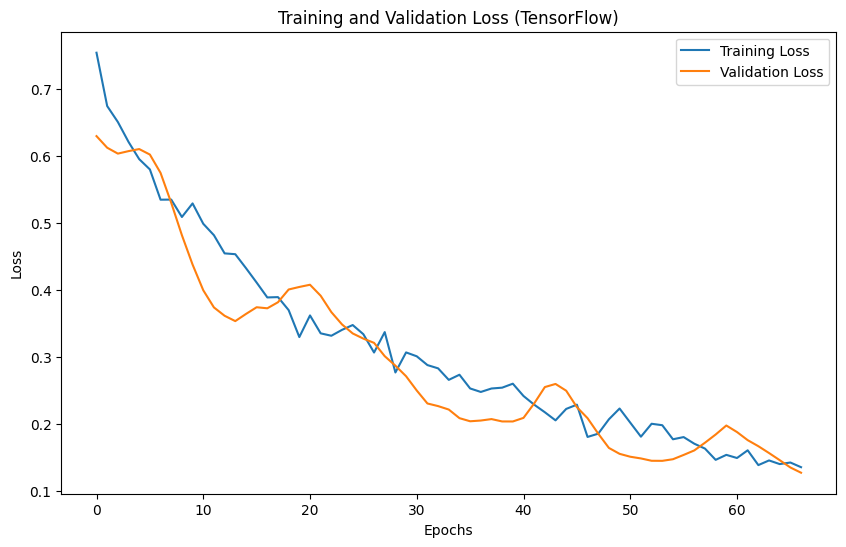

In [17]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (TensorFlow)')
plt.legend()
plt.show()

In [18]:
## evaluation metrics- ROC AUC curve, precision-recall curves, visual confusion matrix